# 07. 기억을 가진 RAG (Memory-Augmented RAG): Store API로 만드는 개인화 RAG

> 지금까지 Part 08에서 만든 RAG들은 모두 **기억상실증**이에요. 사용자가 누구든, 어제 무엇을 물었든 매번 백지에서 시작하죠. 이번 노트북에서는 `07_Memory`에서 배운 **Store API(장기기억)** 를 RAG 그래프 안에 노드로 통합해서, **사용자를 기억하는 개인화 RAG**를 완성해요. Part 08의 캡스톤이에요!

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **체크포인터(단기기억) vs Store(장기기억)** 의 역할 차이를 RAG 맥락에서 설명할 수 있어요
2. `InMemoryStore`에 **의미론적 검색 인덱스**를 설정하고, `("users", user_id)` 네임스페이스를 설계할 수 있어요
3. 노드 함수에 `store: BaseStore`를 주입받아 `memory_load`(기억 읽기) → `memory_save`(기억 쓰기) 노드를 RAG 그래프에 통합할 수 있어요
4. LLM + `with_structured_output()`으로 "이번 대화에서 기억할 가치가 있는 사실"을 **선택적으로 추출·저장**할 수 있어요
5. **교차 스레드 지속성(cross-thread persistence)** 을 시연하여, 새 대화에서도 장기기억이 살아있음을 확인할 수 있어요

## 사전 지식

- `08_RAG/03-CRAG-Self-RAG.ipynb`의 PDF Retriever, `GradeDocuments` 이진 관련성 평가, `format_docs` 패턴
- `07_Memory/01-Short-Term-Memory.ipynb`의 체크포인터(`MemorySaver`)와 `thread_id` 개념
- `07_Memory/02-Long-Term-Memory.ipynb`의 `InMemoryStore`, `put`/`get`/`search`, 네임스페이스 설계

## 왜 RAG에 장기기억이 필요한가요?

같은 질문 "AI 소프트웨어 시장 전망을 알려줘"에 대해서도:

- **입문자**에게는 용어를 풀어서 쉬운 한국어로,
- **전문가**에게는 수치 중심으로 간결하게,
- **지난주에 같은 주제를 물었던 사용자**에게는 "지난번에 이어서"라는 맥락과 함께

답하는 것이 좋은 서비스예요. 이걸 가능하게 하는 재료가 **장기기억**이고, LangGraph에서는 **Store API**가 그 역할을 해요.

### 단기기억 vs 장기기억 복습 (07_Memory 핵심 한 장)

| 구분 | 체크포인터 (checkpointer) | Store |
|------|--------------------------|-------|
| 범위 | `thread_id` 기반 — **한 대화 안** | `namespace` 기반 — **여러 대화(스레드) 간 공유** |
| 내용 | 그래프 상태 스냅샷 (메시지, 중간 결과) | 사용자 선호, 과거 Q&A 에피소드 등 지식 |
| 비유 | 작업 책상 위의 메모 | 서랍 속 고객 카드 |
| compile 인자 | `compile(checkpointer=...)` | `compile(store=...)` |

> 🔑 **핵심 개념**: 장기기억 네임스페이스에는 **`thread_id`를 절대 넣지 않아요.** `("users", user_id)`처럼 사용자 기준으로만 구성해야, 대화(스레드)가 바뀌어도 같은 기억에 접근할 수 있어요. `thread_id`를 넣는 순간 교차 스레드 공유가 깨져요.

### 이번에 만들 그래프

```mermaid
flowchart LR
    S([START]) --> ML[memory_load<br/>장기기억 검색]
    ML --> R[retrieve<br/>PDF 벡터 검색]
    R --> G[grade_documents<br/>관련성 평가]
    G -->|관련 문서 있음| GEN[generate<br/>기억 주입 개인화 답변]
    G -->|관련 문서 없음·재시도 가능| QR[query_rewrite] --> R
    GEN --> MS[memory_save<br/>기억할 사실 추출·저장]
    MS --> E([END])
```

기존 RAG(retrieve → grade → generate)의 **앞에 `memory_load`, 뒤에 `memory_save`** 를 끼워 넣은 구조예요.

- `memory_load`: `store.search()`로 사용자 선호·과거 에피소드를 읽어 state에 주입해요
- `generate`: 검색 문서(`Inform`)에 더해 **장기기억도 프롬프트에 주입**해요 — Inform의 심화 버전이에요
- `memory_save`: LLM이 "기억할 가치가 있는 사실"을 추출(`with_structured_output`)해서 `store.put()`으로 저장해요

> 💡 **실무 팁**: `memory_save`는 반드시 **답변 생성이 끝난 뒤(END 직전)** 에 실행해요. 대화 중간에 실행하면 불완전한 컨텍스트에서 추출이 일어나 기억 품질이 떨어져요.

## 1. 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 설정
# ---------------------------------------------------
# dotenv: .env 파일에서 API 키를 읽어와요
from dotenv import load_dotenv

# API 키 정보 로드 (OPENAI_API_KEY 등)
load_dotenv(override=True)

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정
# ---------------------------------------------------
# LangSmith를 사용하면 memory_load/memory_save 노드의 실행을 시각적으로 추적할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-RAG-Memory-Augmented"

## 2. PDF Retriever 재구성 (03장과 동일)

`03-CRAG-Self-RAG.ipynb`에서 사용한 것과 **완전히 동일한 설정**으로 PDF Retriever를 다시 만들어요. 이번 노트북의 초점은 검색이 아니라 **기억**이니까, 검색 부분은 익숙한 구성을 그대로 재사용해요.

**실습 문서**: 소프트웨어정책연구소(SPRi) AI Brief 2023년 12월호  
파일명: `data/SPRI_AI_Brief_2023년12월호_F.pdf`

In [3]:
# ---------------------------------------------------
# PDF 로더, 임베딩, 벡터스토어 설정 (03장과 동일)
# ---------------------------------------------------
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# PDF 파일 로드 (SPRI AI Brief 2023년 12월호)
PDF_PATH = "data/SPRI_AI_Brief_2023년12월호_F.pdf"

# 페이지 단위로 문서 로드
loader = PyPDFLoader(PDF_PATH)
pages = loader.load()
print(f"총 {len(pages)}페이지 로드 완료")

# 청크로 분할 (03장과 동일한 설정)
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
)
docs = splitter.split_documents(pages)
print(f"총 {len(docs)}개 청크 생성")

# OpenAI 임베딩 + FAISS 벡터스토어 생성
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(docs, embeddings)

# Retriever 생성 (유사도 기반, 상위 4개 문서 반환)
pdf_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
# Retriever 준비 완료

총 23페이지 로드 완료
총 85개 청크 생성


In [4]:
# ---------------------------------------------------
# LLM + 개인화 RAG 프롬프트 구성
# ---------------------------------------------------
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 기본 모델: gpt-4o-mini (비용 효율)
llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

# 개인화 RAG 프롬프트: 기존 RAG 프롬프트에 {memory_context} 슬롯이 추가됐어요
# → 장기기억(사용자 선호, 과거 에피소드)이 이 자리에 주입돼요
PERSONALIZED_RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant. Answer the question based on the provided context.
If the context doesn't contain enough information, say so clearly.
Always cite your sources by mentioning the document name and page number.

Here is what you remember about this user from previous conversations.
Adapt your answer style (language, difficulty, format) to these memories.
If the memory section is empty, just answer in plain Korean.

<user_memory>
{memory_context}
</user_memory>"""),
    ("human", """Context: {context}

Question: {question}""")
])


def format_docs(docs):
    """문서 리스트를 프롬프트 입력 형식으로 포맷팅해요. (03장과 동일한 XML 패턴)"""
    return "\n\n".join(
        f"<document>\n<content>{doc.page_content}</content>\n"
        f"<source>{doc.metadata.get('source', 'unknown')}</source>\n"
        f"<page>{doc.metadata.get('page', 0) + 1}</page>\n</document>"
        for doc in docs
    )


# 개인화 RAG 체인: 프롬프트 → LLM → 텍스트 파서
personalized_rag_chain = PERSONALIZED_RAG_PROMPT | llm | StrOutputParser()
# RAG 체인 준비 완료

## 3. 장기기억 저장소 구성

### 3-1. InMemoryStore + 의미론적 검색 인덱스

`07_Memory/02-Long-Term-Memory.ipynb`에서는 `InMemoryStore()`를 기본 설정으로 썼어요. 이번에는 한 단계 더 나아가 **`index` 파라미터로 임베딩 인덱스**를 설정해요. 그러면 `store.search(namespace, query="...")`가 키워드가 아니라 **의미 기반**으로 기억을 찾아줘요 — 벡터스토어 검색과 같은 원리예요.

> ⚠️ **자주 하는 실수**: `index` 설정 없이 `query=`를 넘기면 의미론적 검색이 동작하지 않아요(필터 없는 전체 조회처럼 동작할 수 있어요). 의미 검색을 쓰려면 반드시 `InMemoryStore(index={...})`로 만들어야 해요.

### 네임스페이스 설계 가이드

| 원칙 | 예시 | 이유 |
|------|------|------|
| 최소 2-tuple: `(범위, user_id)` | `("users", "alice")` | 사용자별 격리 + 범위 구분 |
| `thread_id`는 절대 포함 금지 | `("users", "alice")` ⭕ / `("users", "alice", thread_id)` ❌ | 교차 스레드 공유가 목적이니까요 |
| 데이터 종류가 많아지면 계층 분리 | `("users", uid, "profile")`, `("users", uid, "episodes")` | 검색 범위를 좁혀 노이즈 감소 |

이번 노트북에서는 단순하게 `("users", user_id)` 하나의 네임스페이스에 `type` 필드(`preference`/`episode`)로 종류를 구분할게요.

In [5]:
# ---------------------------------------------------
# InMemoryStore 생성 (의미론적 검색 인덱스 포함)
# ---------------------------------------------------
# 개발/교육용 인메모리 저장소예요 (프로덕션: PostgresStore)
import uuid
from langgraph.store.memory import InMemoryStore

# index: 기억을 임베딩하여 의미 기반 search(query=...)를 가능하게 해요
# 위에서 만든 text-embedding-3-small 임베딩 객체를 재사용해요 (dims=1536)
memory_store = InMemoryStore(
    index={
        "embed": embeddings,
        "dims": 1536,
    }
)

# ---------------------------------------------------
# 시나리오용 사용자 선호 시딩 (과거 대화에서 쌓였다고 가정)
# ---------------------------------------------------
# 사용자 A: AI 입문자 — 쉬운 한국어 설명 선호
memory_store.put(
    ("users", "user_a"),          # namespace: thread_id 없이 사용자 기준!
    str(uuid.uuid4()),             # key: 누적형 기억이므로 매번 새 uuid
    {
        "type": "preference",
        "note": "AI 입문자예요. 전문 용어는 반드시 풀어서, 쉬운 한국어로 설명해 주세요. 비유를 좋아해요.",
    },
)

# 사용자 B: AI 업계 전문가 — 영어, 수치 중심 선호
memory_store.put(
    ("users", "user_b"),
    str(uuid.uuid4()),
    {
        "type": "preference",
        "note": "AI industry expert. Prefers answers in English, concise bullet points with concrete numbers. No basic explanations.",
    },
)

print("사용자 선호 시딩 완료: user_a(입문자·한국어), user_b(전문가·영어)")

사용자 선호 시딩 완료: user_a(입문자·한국어), user_b(전문가·영어)


### 3-2. 문서 관련성 평가기 (03장 패턴 재사용)

`03-CRAG-Self-RAG.ipynb`에서 만든 **이진(yes/no) 관련성 평가기**를 그대로 재사용해요. 검색 결과를 그대로 믿지 않고 한 번 점검하는 **Verify** 단계예요.

In [6]:
# ---------------------------------------------------
# 문서 관련성 평가기 (Retrieval Grader) — 03장 재사용
# ---------------------------------------------------
from pydantic import BaseModel, Field


class GradeDocuments(BaseModel):
    """검색된 문서의 관련성을 평가하는 이진 점수예요."""

    binary_score: str = Field(
        description="문서가 질문과 관련이 있으면 'yes', 없으면 'no'"
    )


# 구조화된 출력: LLM이 GradeDocuments 형식으로만 응답하도록 강제해요
structured_llm_grader = llm.with_structured_output(GradeDocuments)

grade_system = """You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keywords or semantic meaning related to the question, grade it as relevant.
Give a binary score 'yes' or 'no' to indicate whether the document is relevant."""

grade_prompt = ChatPromptTemplate.from_messages([
    ("system", grade_system),
    ("human", "Retrieved document:\n\n{document}\n\nUser question: {question}"),
])

retrieval_grader = grade_prompt | structured_llm_grader
# 관련성 평가기 준비 완료

### 3-3. 기억 추출기 (Memory Extractor)

`memory_save` 노드의 두뇌예요. 이번 Q&A에서 **"다음 대화에도 쓸모 있는 사실"** 이 있는지 LLM이 판단하고, 있으면 한 문장으로 추출해요.

> 🔑 **핵심 개념**: 모든 대화를 통째로 저장하면 기억이 **노이즈**가 돼요. `worth_saving` 필드로 **선택적 저장**을 강제하는 것이 포인트예요 — 저장할 가치가 없으면 `no`를 반환하고 아무것도 저장하지 않아요.

In [7]:
# ---------------------------------------------------
# 기억 추출기 (Memory Extractor)
# ---------------------------------------------------


class MemoryFact(BaseModel):
    """이번 대화에서 장기기억으로 저장할 사실이에요."""

    worth_saving: str = Field(
        description="다음 대화에도 유용한 사실이 있으면 'yes', 없으면 'no'"
    )
    note: str = Field(
        description="기억할 사실 한 문장 (사용자의 관심 주제, 질문 이력 등). worth_saving이 'no'면 빈 문자열"
    )


memory_extractor_llm = llm.with_structured_output(MemoryFact)

extract_system = """You are a memory curator for a personalized RAG system.
Given a user's question and the answer they received, decide whether there is a fact
worth remembering for FUTURE conversations (e.g., topics the user is interested in,
questions already asked and answered).
Do NOT save generic facts about the document itself — only user-centric facts.
Write the note in Korean, one sentence."""

extract_prompt = ChatPromptTemplate.from_messages([
    ("system", extract_system),
    ("human", "질문: {question}\n\n답변: {generation}"),
])

memory_extractor = extract_prompt | memory_extractor_llm
# 기억 추출기 준비 완료

## 4. 그래프 구성

### 4-1. 상태(State) 정의

기존 RAG 상태에 `memory_context`(장기기억 텍스트)와 `retry_count`(재검색 가드)가 추가됐어요.

In [8]:
# ---------------------------------------------------
# Memory-Augmented RAG 상태(State) 정의
# ---------------------------------------------------
from typing import Annotated, List
from typing_extensions import TypedDict


class MemRAGState(TypedDict):
    """Memory-Augmented RAG 그래프의 상태 정의예요."""

    question: Annotated[str, "사용자 질문"]
    generation: Annotated[str, "생성된 답변"]
    documents: Annotated[List, "검색된 문서 리스트"]
    memory_context: Annotated[str, "store에서 읽어온 장기기억 텍스트"]
    retry_count: Annotated[int, "쿼리 재작성 재시도 횟수 (무한 루프 방지)"]

### 4-2. 노드 함수 정의 — store는 어떻게 주입되나요?

노드 함수 시그니처를 다음처럼 선언하면, `compile(store=...)` 시점에 LangGraph가 **store를 자동 주입**해 줘요:

```python
def memory_load(state, config: RunnableConfig, *, store: BaseStore):
```

> ⚠️ **자주 하는 실수**: `store`는 반드시 `*` 뒤의 **keyword-only 파라미터**여야 해요. 일반 positional 파라미터로 두면 LangGraph가 주입해 주지 않아요.

`user_id`는 `config["configurable"]["user_id"]`로 전달받아요 — `thread_id`와 같은 통로지만, 용도가 달라요(`thread_id`=대화 식별, `user_id`=사람 식별).

In [9]:
# ---------------------------------------------------
# 노드 함수 정의
# ---------------------------------------------------
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore


def memory_load(state: MemRAGState, config: RunnableConfig, *, store: BaseStore) -> dict:
    """장기기억을 검색하여 state에 주입하는 노드예요."""
    # ==== [MEMORY LOAD] ====
    user_id = config["configurable"].get("user_id", "anonymous")
    namespace = ("users", user_id)

    # 의미론적 검색: 현재 질문과 관련 있는 기억 상위 4개를 가져와요
    memories = store.search(namespace, query=state["question"], limit=4)

    if memories:
        memory_context = "\n".join(
            f"- [{m.value.get('type', 'memory')}] {m.value['note']}" for m in memories
        )
    else:
        memory_context = ""  # 신규 사용자: 기억 없음 → 기본 동작

    return {"memory_context": memory_context, "retry_count": 0}


def retrieve(state: MemRAGState) -> dict:
    """PDF 벡터 검색 노드예요."""
    # ==== [RETRIEVE] ====
    documents = pdf_retriever.invoke(state["question"])
    return {"documents": documents}


def grade_documents(state: MemRAGState) -> dict:
    """문서 관련성 평가 노드예요. 관련 없는 문서를 필터링해요. (03장 패턴)"""
    # ==== [GRADE DOCUMENTS] ====
    question = state["question"]

    filtered_docs = []
    for d in state["documents"]:
        score = retrieval_grader.invoke({
            "question": question,
            "document": d.page_content,
        })
        if score.binary_score == "yes":
            filtered_docs.append(d)

    return {"documents": filtered_docs}


def query_rewrite(state: MemRAGState) -> dict:
    """관련 문서가 없을 때 질문을 검색 친화적으로 재작성하는 노드예요."""
    # ==== [QUERY REWRITE] ====
    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", "Rewrite the question to be optimized for vector search. "
                   "Output only the improved question in Korean."),
        ("human", "{question}"),
    ])
    better_question = (rewrite_prompt | llm | StrOutputParser()).invoke(
        {"question": state["question"]}
    )
    return {"question": better_question, "retry_count": state["retry_count"] + 1}


def generate(state: MemRAGState) -> dict:
    """장기기억을 주입한 개인화 답변 생성 노드예요."""
    # ==== [GENERATE] ====
    context = format_docs(state["documents"]) if state["documents"] else "관련 문서를 찾을 수 없습니다."

    generation = personalized_rag_chain.invoke({
        "context": context,
        "question": state["question"],
        "memory_context": state["memory_context"] or "(no memories yet)",
    })
    return {"generation": generation}


def memory_save(state: MemRAGState, config: RunnableConfig, *, store: BaseStore) -> dict:
    """이번 Q&A에서 기억할 사실을 추출하여 store에 저장하는 노드예요.

    END 직전에 실행해요 — 답변까지 완성된 '완전한 컨텍스트'에서 추출해야 품질이 좋아요.
    """
    # ==== [MEMORY SAVE] ====
    user_id = config["configurable"].get("user_id", "anonymous")
    namespace = ("users", user_id)

    fact = memory_extractor.invoke({
        "question": state["question"],
        "generation": state["generation"],
    })

    if fact.worth_saving == "yes" and fact.note:
        # 누적형 기억: key를 매번 새 uuid로 생성해요 (같은 key로 put하면 덮어써요!)
        store.put(namespace, str(uuid.uuid4()), {
            "type": "episode",
            "note": fact.note,
            "question": state["question"],
        })
        #   ✓ 기억 저장됨
    #   ✗ worth_saving == 'no' → 저장 생략 (노이즈 방지)

    return {}

### 4-3. 조건부 엣지 함수

관련 문서가 하나도 없으면 **1회에 한해** 질문을 재작성하고 다시 검색해요. `retry_count`로 무한 루프를 방지해요 (03장의 `GraphRecursionError` 교훈!).

In [10]:
# ---------------------------------------------------
# 조건부 엣지 함수
# ---------------------------------------------------


def decide_to_generate(state: MemRAGState) -> str:
    """문서 평가 결과에 따라 다음 단계를 결정하는 라우팅 함수예요.

    Returns:
        'query_rewrite': 관련 문서가 없고 아직 재시도하지 않은 경우
        'generate': 관련 문서가 있거나, 이미 1회 재시도한 경우
    """
    # ==== [DECIDE TO GENERATE] ====
    if len(state["documents"]) == 0 and state["retry_count"] < 1:
        # 관련 문서 없음 + 재시도 여유 있음 → 쿼리 재작성
        return "query_rewrite"
    # 관련 문서 있음 (또는 재시도 소진) → 답변 생성
    return "generate"

### 4-4. 그래프 조립 및 시각화

`compile()`에 **두 가지 메모리를 동시에** 연결하는 것이 이번 노트북의 하이라이트예요:

- `checkpointer=MemorySaver()` → 단기기억 (스레드 안 상태)
- `store=memory_store` → 장기기억 (스레드 간 공유)

In [11]:
# ---------------------------------------------------
# Memory-Augmented RAG 그래프 조립
# ---------------------------------------------------
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(MemRAGState)

# 노드 등록
workflow.add_node("memory_load", memory_load)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("query_rewrite", query_rewrite)
workflow.add_node("generate", generate)
workflow.add_node("memory_save", memory_save)

# 엣지 연결
workflow.add_edge(START, "memory_load")            # 시작 → 장기기억 로드
workflow.add_edge("memory_load", "retrieve")       # 기억 로드 → 검색
workflow.add_edge("retrieve", "grade_documents")   # 검색 → 관련성 평가

# 조건부 엣지: 관련 문서 유무에 따라 분기
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "query_rewrite": "query_rewrite",  # 관련 문서 없음 → 재작성
        "generate": "generate",            # 관련 문서 있음 → 생성
    },
)
workflow.add_edge("query_rewrite", "retrieve")     # 재작성 → 다시 검색
workflow.add_edge("generate", "memory_save")       # 생성 → 기억 저장 (END 직전!)
workflow.add_edge("memory_save", END)

# 컴파일: 단기기억(checkpointer) + 장기기억(store)을 동시에 연결해요
checkpointer = MemorySaver()
mem_rag_app = workflow.compile(
    checkpointer=checkpointer,   # thread_id 기반 — 대화 안 상태
    store=memory_store,          # namespace 기반 — 대화 간 공유
)
# 그래프 컴파일 완료

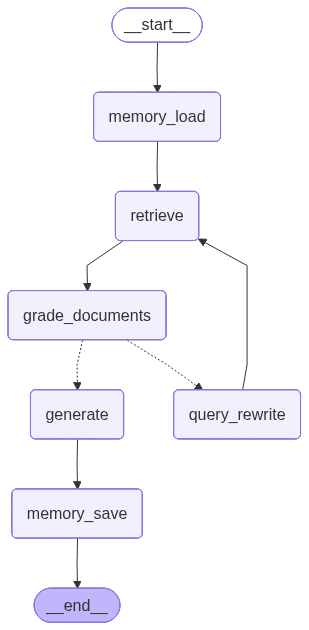

In [12]:
# ---------------------------------------------------
# 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → memory_load → retrieve → grade_documents → (generate | query_rewrite → retrieve) → memory_save → END
# memory_load: store.search()로 사용자 선호·과거 에피소드를 state에 주입해요
# grade_documents: 03장과 동일한 이진 관련성 평가 + 필터링이에요
# generate: 검색 문서 + 장기기억을 함께 프롬프트에 주입한 개인화 생성이에요
# memory_save: 기억할 사실을 추출하여 store.put()으로 저장해요 (END 직전)
from IPython.display import Image, display

display(Image(mem_rag_app.get_graph().draw_mermaid_png()))

## 5. 실행 테스트 — 같은 질문, 다른 사용자, 다른 답변

세 가지 시나리오로 장기기억의 효과를 확인해요:

1. **user_a (입문자)**: 같은 질문 → 쉬운 한국어 + 비유 중심 답변이 나와야 해요
2. **user_b (전문가)**: 같은 질문 → 영어 + 수치 중심 불릿 답변이 나와야 해요
3. **user_a, 새 thread_id**: 대화가 바뀌어도(체크포인터는 초기화) **장기기억은 살아있어요** — 교차 스레드 지속성

In [13]:
# ---------------------------------------------------
# 시나리오 1: user_a (입문자) — 쉬운 한국어 답변 기대
# ---------------------------------------------------
from langchain_core.runnables import RunnableConfig

QUESTION = "AI 소프트웨어 시장 전망을 알려줘"

config_a = RunnableConfig(
    recursion_limit=10,
    configurable={
        "thread_id": "thread_a_1",   # 대화 식별 (단기기억)
        "user_id": "user_a",         # 사람 식별 (장기기억 namespace)
    },
)

result_a = mem_rag_app.invoke({"question": QUESTION}, config_a)

print("[user_a에게 주입된 장기기억]")
print(result_a["memory_context"])
print("\n[user_a의 답변]")
print(result_a["generation"])

[user_a에게 주입된 장기기억]
- [preference] AI 입문자예요. 전문 용어는 반드시 풀어서, 쉬운 한국어로 설명해 주세요. 비유를 좋아해요.

[user_a의 답변]
AI 소프트웨어 시장은 앞으로 급성장할 것으로 예상됩니다. 시장조사기관 IDC에 따르면, AI 소프트웨어 시장의 매출은 2022년 640억 달러에서 2027년에는 2,510억 달러에 이를 것으로 보이며, 이 기간 동안 연평균 성장률은 31.4%에 달할 것으로 전망하고 있습니다.

특히, AI 애플리케이션이 가장 큰 시장을 차지하며, 2023년 전체 매출의 약 3분의 1을 차지할 것으로 예상됩니다. 이 분야는 2027년까지 연평균 21.1%의 성장률을 기록할 것으로 보입니다. 또한, AI 플랫폼과 애플리케이션도 중요한 역할을 하며, 이 부문은 2027년까지 35.8%의 연평균 성장률이 예상됩니다.

AI 소프트웨어 시장의 주요 분야로는 AI 플랫폼, AI 애플리케이션, AI 시스템 인프라 소프트웨어(SIS), 그리고 AI 애플리케이션 개발 및 배포(AI AD&D) 소프트웨어가 포함됩니다. 특히 AI AD&D는 향후 5년간 가장 높은 38.7%의 성장률을 기록할 것으로 보입니다. 

이러한 성장세는 기업들이 AI와 자동화 기술에 대한 투자를 계속하고 있다는 점에서 나타나며, AI 도입이 사업 성공과 경쟁 우위에 필수적이라고 인식하고 있습니다. (출처: SPRi AI Brief, 2023년 12월호, 15페이지)


In [14]:
# ---------------------------------------------------
# 시나리오 2: user_b (전문가) — 같은 질문, 영어·수치 중심 답변 기대
# ---------------------------------------------------
config_b = RunnableConfig(
    recursion_limit=10,
    configurable={
        "thread_id": "thread_b_1",
        "user_id": "user_b",         # namespace가 ("users", "user_b")로 바뀌어요
    },
)

result_b = mem_rag_app.invoke({"question": QUESTION}, config_b)

print("[user_b에게 주입된 장기기억]")
print(result_b["memory_context"])
print("\n[user_b의 답변]")
print(result_b["generation"])

[user_b에게 주입된 장기기억]
- [preference] AI industry expert. Prefers answers in English, concise bullet points with concrete numbers. No basic explanations.

[user_b의 답변]
- **2022-2027 Growth**: AI 소프트웨어 시장, 2022년 640억 달러에서 2027년 2,510억 달러로 성장.
- **CAGR**: 연평균 성장률 31.4%.
- **AI 애플리케이션**: 2023년 전체 매출의 약 1/3 차지, 2027년까지 21.1%의 CAGR 예상.
- **AI 플랫폼**: 두 번째로 큰 시장, 2027년까지 35.8%의 CAGR 예상.
- **AI AD&D**: 가장 높은 성장률, 38.7%의 CAGR 예상.
- **생성 AI**: 2027년까지 283억 달러 매출 전망.

(Source: SPRi AI Brief, 2023-12월호, p. 15)


### 출력 해설

위 두 출력에서 장기기억이 답변 스타일을 어떻게 바꿨는지 비교해 보세요:

- **user_a**: `memory_context`에 "AI 입문자… 쉬운 한국어…" 선호가 주입됐고, 답변이 **풀어쓴 문장 중심의 한국어 서술형**으로 나왔어요 ("앞으로 급성장할 것으로 예상됩니다…")
- **user_b**: 같은 질문·같은 PDF 문서인데도 `memory_context`의 "expert… English… bullet points" 선호 때문에 **불릿 + 수치(CAGR 31.4%, 2,510억 달러 등) 중심의 압축형** 답변이 나왔어요
- 두 실행 모두 마지막에 `memory_save`가 돌면서 "사용자는 AI 소프트웨어 시장 전망에 관심이 있다" 같은 **에피소드 기억**이 각자의 namespace에 추가돼요 — 바로 다음 시나리오에서 확인할 거예요

### 시나리오 3: 교차 스레드 지속성 (Cross-Thread Persistence)

이제 **완전히 새로운 대화**(`thread_id`가 다름)를 시작해 볼게요. 체크포인터 관점에서는 백지 상태지만, `user_id`가 같으므로 `("users", "user_a")` namespace의 기억은 그대로 살아있어요.

In [15]:
# ---------------------------------------------------
# 시나리오 3: user_a, 새 thread → 장기기억은 살아있어요
# ---------------------------------------------------
import uuid

config_a_new_thread = RunnableConfig(
    recursion_limit=10,
    configurable={
        "thread_id": str(uuid.uuid4()),  # 완전히 새로운 대화!
        "user_id": "user_a",             # 같은 사람 → 같은 장기기억
    },
)

result_a2 = mem_rag_app.invoke(
    {"question": "삼성전자가 공개한 생성 AI에 대해 알려줘"},
    config_a_new_thread,
)

print("[새 스레드인데도 주입된 장기기억]")
print(result_a2["memory_context"])
print("\n[답변]")
print(result_a2["generation"])

# ---------------------------------------------------
# user_a의 장기기억 전체 확인 (선호 + 누적된 에피소드)
# ---------------------------------------------------
print("\n[store에 쌓인 user_a의 기억 전체]")
for item in memory_store.search(("users", "user_a"), limit=10):
    print(f"  - ({item.value.get('type')}) {item.value['note']}")

[새 스레드인데도 주입된 장기기억]
- [episode] 사용자는 AI 소프트웨어 시장 전망에 관심이 있으며, 이와 관련된 성장률과 주요 분야에 대한 정보를 알고 싶어한다.
- [preference] AI 입문자예요. 전문 용어는 반드시 풀어서, 쉬운 한국어로 설명해 주세요. 비유를 좋아해요.

[답변]
삼성전자가 공개한 생성 AI 모델은 '삼성 가우스'입니다. 이 모델은 언어, 코드, 이미지의 세 가지 모델로 구성되어 있으며, 온디바이스에서 작동할 수 있도록 설계되었습니다. 즉, 사용자의 정보가 외부로 유출될 위험이 없다는 장점이 있습니다.

삼성 가우스는 다음과 같은 기능을 제공합니다:

1. **언어 모델**: 이메일 작성, 문서 요약, 번역 등의 작업을 지원합니다.
2. **코드 모델**: AI 코딩 어시스턴트인 '코드아이(code.i)'를 통해 대화형 인터페이스로 소프트웨어 개발을 도와줍니다.
3. **이미지 모델**: 창의적인 이미지를 생성하거나 기존 이미지를 수정할 수 있으며, 저해상도 이미지를 고해상도로 변환하는 기능도 포함되어 있습니다.

삼성전자는 이 AI 기술을 다양한 제품에 단계적으로 탑재할 계획이며, 2024년부터 삼성 스마트폰이 다른 경쟁 제품들과 경쟁할 것으로 예상하고 있습니다 (출처: SPRi AI Brief, 2023년 12월호, 페이지 13).

[store에 쌓인 user_a의 기억 전체]
  - (preference) AI 입문자예요. 전문 용어는 반드시 풀어서, 쉬운 한국어로 설명해 주세요. 비유를 좋아해요.
  - (episode) 사용자는 AI 소프트웨어 시장 전망에 관심이 있으며, 이와 관련된 성장률과 주요 분야에 대한 정보를 알고 싶어한다.
  - (episode) 사용자는 삼성전자가 공개한 생성 AI 모델인 '삼성 가우스'에 관심이 있으며, 이 모델의 기능과 특징에 대해 알고 있다.


**출력 해설**: 새 스레드인데도 `memory_context`에 입문자 선호와 함께, 시나리오 1에서 `memory_save`가 저장한 **"AI 소프트웨어 시장 전망에 관심"** 에피소드까지 주입된 것을 볼 수 있어요. 마지막 store 덤프에는 `preference` 1건 + `episode` 2건(시나리오 1, 3)이 쌓여 있어요 — 체크포인터(단기기억)는 스레드가 바뀌면 백지가 되지만, Store(장기기억)는 사용자를 따라다닌다는 것이 핵심이에요.

## 6. 운영 시 고려사항

### memory_save를 매 턴 실행하면 생기는 문제

| 문제 | 설명 | 대안 |
|------|------|------|
| **비용** | 매 턴 LLM 추출 호출 1회 추가 (답변 생성과 별개) | N턴마다 또는 대화 종료 시 **요약 후 일괄 저장** |
| **노이즈** | 사소한 잡담까지 저장되면 `memory_load` 검색 품질이 떨어져요 | 이번 노트북처럼 `worth_saving` **선택적 저장** + `limit`으로 주입량 제한 |
| **중복** | 같은 사실이 여러 번 저장될 수 있어요 | 저장 전 `store.search()`로 유사 기억 확인 후 병합(upsert) |

### 프로덕션 체크리스트

- `InMemoryStore`는 프로세스가 꺼지면 **모든 기억이 사라져요**. 실서비스에서는 `07_Memory/02-Long-Term-Memory.ipynb`에서 언급한 대로 **`PostgresStore`** (`from langgraph.store.postgres import PostgresStore`)를 쓰세요
- 기억 주입량은 토큰 비용이에요 — `search(limit=...)`을 작게 유지하고, 오래된 에피소드는 주기적으로 요약·정리하세요
- 참고로 `10_Deep_Agents`에서 만나는 Deep Agents 프레임워크는 이런 **장기기억 통합이 내장**되어 있어요 — 오늘 직접 만든 구조가 그 내부 동작의 축소판이에요

## 실습

**과제: 질문 캐시(Question Cache) 분기 추가하기**

사용자가 **이미 물어본 질문**이면 PDF 검색·생성을 건너뛰고 **저장된 답을 재활용**하는 분기를 추가해 보세요.

구현 가이드:

1. `memory_save`에서 에피소드 저장 시 `"answer": state["generation"]` 필드를 함께 저장하세요
2. `memory_load` 다음에 `check_cache` 라우팅 함수를 추가하세요:
   - `store.search(namespace, query=질문, limit=1)`의 최상위 결과가 **거의 같은 질문**이면(예: LLM에게 yes/no로 물어보기) → `"cached_answer"` 노드로
   - 아니면 → `"retrieve"`로
3. `cached_answer` 노드는 저장된 `answer`를 `generation`에 그대로 넣고 끝내요 (LLM 호출 0회!)
4. `add_conditional_edges("memory_load", check_cache, {...})`로 연결하세요

힌트: 캐시 적중 판단도 `with_structured_output()` + 이진 점수 패턴(`GradeDocuments`와 동일)으로 만들면 돼요.

In [16]:
# ---------------------------------------------------
# 실습: 질문 캐시 분기 추가 (여기에 구현해 보세요)
# ---------------------------------------------------

# TODO 1: memory_save를 수정해 answer 필드도 함께 저장하세요
#   store.put(namespace, str(uuid.uuid4()),
#             {"type": "episode", "note": ..., "question": ..., "answer": state["generation"]})

# TODO 2: 캐시 적중 판단용 Pydantic 모델 + 그레이더를 만드세요
# class SameQuestion(BaseModel):
#     binary_score: str = Field(description="두 질문이 사실상 같으면 'yes', 다르면 'no'")

# TODO 3: cached_answer 노드와 check_cache 라우팅 함수를 작성하세요

# TODO 4: 그래프를 다시 조립하세요
#   workflow.add_conditional_edges("memory_load", check_cache,
#       {"cached_answer": "cached_answer", "retrieve": "retrieve"})

# TODO 5: 같은 user_id로 같은 질문을 두 번 실행해서,
#         두 번째 실행이 retrieve/generate 없이 즉시 답하는지 확인하세요

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Memory-Augmented RAG**: 기존 RAG 그래프의 앞뒤에 `memory_load` / `memory_save` 노드를 끼워 넣어, **사용자를 기억하는 개인화 RAG**를 만들었어요
- **두 가지 메모리 동시 연결**: `compile(checkpointer=MemorySaver(), store=memory_store)` — 체크포인터는 `thread_id` 기반 단기기억, Store는 `namespace` 기반 장기기억이에요
- **store 주입 패턴**: 노드 시그니처 `def node(state, config, *, store: BaseStore)`의 keyword-only `store` 파라미터로 LangGraph가 자동 주입해요
- **네임스페이스 설계**: `("users", user_id)` — `thread_id`를 넣지 않아야 교차 스레드 공유가 유지돼요
- **선택적 저장**: `MemoryFact.worth_saving`(이진 판단)으로 노이즈 저장을 막고, 누적 기억은 `str(uuid.uuid4())` 키로 저장해요 (같은 키 put은 덮어쓰기!)
- **5가지 사고 도구 매핑**: 이 패턴 = **Inform의 심화**(검색 문서에 더해 장기기억까지 프롬프트에 주입) + **Verify**(이진 관련성 체크 재사용)

### Part 08 RAG 전체 정리

Part 08에서 배운 모든 RAG 기법을 한눈에 정리해요:

| 노트북 | 핵심 기법 | 해결하는 문제 | 비용 수준 |
|--------|----------|-------------|----------|
| **01** Naive RAG | Retrieve → Generate | 기본 문서 Q&A | 낮음 |
| **02** Agentic RAG | 관련성 체크 + 웹 폴백 + 에이전트 자율 판단 | 무한 루프, 불필요한 검색 | 중간 |
| **03** CRAG/Self-RAG | 검색 보강(CRAG) + 생성 품질 검증(Self-RAG) | 검색 실패, 환각 | 중-높음 |
| **04** Adaptive RAG | 사전 라우팅 + 3단계 검증 | 소스 선택, 비용 최적화 | 높음 |
| **05** Retrieval | 쿼리 강화 + MMR + 메타데이터 필터링 | 검색 품질 자체 개선 | 가변 |
| **06** Critic 루프 | 점수 기반 critic 루프 | 품질-비용 세밀 제어 | 중-높음 |
| **07** Memory-Augmented RAG | 장기기억 통합 | 개인화·반복 질문 | 중간 |

> 🔗 **벡터 RAG를 넘어서 — 관계형 질문이 주가 되는 경우**: 위 기법들은 모두 **벡터 검색**을 중심으로 해요. 데이터가 문서가 아니라 **엔티티·관계의 그래프**라면(예: "이 약과 상호작용하는 약은?", "이 인물과 공저자인 사람은?"), `11_Use_Cases/06-GraphRAG-Neo4j.ipynb`의 **Text2Cypher** 파이프라인이 더 정확해요. 벡터 RAG와 GraphRAG는 대체재가 아니라 **보완재**이며, 실제 프로덕션에서는 Part 09의 Router·Supervisor로 둘을 병렬 배치하는 경우가 많아요.

> 🎯 **강의 포인트**: RAG 시스템 구축은 **점진적 개선**이 핵심이에요. Naive RAG로 시작해서 LangSmith로 병목을 찾고, 필요한 기법만 추가하세요. "처음부터 Adaptive RAG"는 과잉 엔지니어링이에요.

### 5가지 사고 도구 관점에서 본 Part 08

| 패턴 | 주로 사용한 도구 | 역할 |
|------|----------------|------|
| **Naive RAG** (01) | **Inform** | 검색 결과를 프롬프트에 주입 |
| **Agentic RAG** (02) | Inform + **Verify** + **Constrain** | 관련성 그레이더 + 에이전트가 검색 필요성 자율 판단 |
| **CRAG / Self-RAG** (03) | Inform + Verify + **Correct** | 관련성·환각 점검 후 쿼리 재작성 또는 웹 폴백으로 교정 |
| **Adaptive RAG** (04) | 네 도구(Inform+Constrain+Verify+Correct) 전부 | 라우팅으로 Constrain, 3단계 체크로 Verify/Correct |
| **Retrieval 심화** (05) | Inform + Constrain | 메타데이터 필터·MMR로 컨텍스트 품질과 범위 제한 |
| **Critic 루프** (06) | **Verify + Correct 심화** | 점수 기반 평가로 품질-비용을 세밀하게 제어 |
| **Memory-Augmented RAG** (07) | **Inform 심화** + Verify | 검색 문서 + 장기기억을 함께 주입하는 개인화 Inform |

## 다음 챕터 예고 — Part 09 Multi-Agent로 이어져요

Part 08에서 완성한 RAG 패턴들은 **혼자 일하는 에이전트가 검색을 잘 쓰는 법**이에요. Part 09에서는 시야를 넓혀, 여러 에이전트가 역할을 나눠 협력하는 **멀티에이전트 아키텍처**를 배워요.

- **`09_Multi_Agent/01-Multi-Agent-Overview.ipynb`**: Supervisor / Collaboration / Handoff / Router / Hierarchical 다섯 가지 협력 패턴 개관
- RAG와의 연결: 이번 챕터에서 만든 RAG 그래프들은 **Researcher 에이전트의 sub-graph**로 그대로 끼워 넣을 수 있어요. Supervisor 밑에 "문서 RAG 에이전트 + 웹 검색 에이전트 + 코드 분석 에이전트"를 두면, 오늘 만든 Memory-Augmented RAG가 그중 한 Worker가 돼요 — 장기기억 store는 모든 Worker가 공유할 수도 있어요
- 이후 **Part 10 Deep Agents**에서는 이 멀티에이전트 구조를 한 단계 더 추상화한 프레임워크(파일시스템·서브에이전트·**장기 메모리 내장**)를 만나요 — 오늘 직접 만든 memory_load/memory_save가 거기서는 프레임워크 기능으로 제공돼요

> 💡 **학습 전략**: 멀티에이전트 패턴을 공부할 때도 **5가지 사고 도구**로 각 패턴을 분해해보세요. Supervisor = Constrain(경로 제한) + Inform(상태 공유), Evaluator subgraph = Verify + Correct — 이런 식으로 이름이 바뀌어도 근본 원리는 그대로예요.